In [1]:
import sys
sys.path.insert(0, '.')

from barcodes.barcodes import BarcodeType, Barcode, TRUE_KEY, SUBSET_KEY, PRETTY_PRINT_MAP
from classifiers.cnn_classifier import CNNBarcodeClassifier, DEFAULT_CONV_ARCH, SharedImageCache
from classifiers.accurate_subset_classifier import AccurateSubsetClassifier
from classifiers.perfect_classifier import PerfectClassifier
from solvers.cnn_solver import ZXingCppCNNSolver
from solvers.abstract_solver import AbstractBarcodeSolver
from utils.dataset_parsers import parse_all_datasets
from utils.barcode_storage import BarcodeStorage
from utils.subsets_decomposition import (
    get_all_partitions_2_107_decomposition,
    get_all_partitions_2_108_decomposition,
    get_all_partitions_3_672_decomposition,
    get_all_partitions_3_681_decomposition,
    get_all_partitions_3_888_decomposition,
    get_all_partitions_3_891_decomposition,
)
from tools.tex_tables_builder import dataframe_to_latex_table, paired_dataframes_to_latex_table, save_group

from copy import deepcopy
from typing import Dict, List
import pandas as pd
import numpy as np
import random
import os
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

%load_ext autoreload
%autoreload 2

In [2]:
MARGIN_RATE = 0.1
SOLVER_NAME = "ZxingCppCNN"
GRAPHS_DIR = "../graphs"
CNN_TABLES_GROUP = "cnn_pipeline"

PARTITIONS = ["2_107", "2_108", "3_672", "3_681", "3_888", "3_891"]

RESOLUTIONS = [16, 24, 32, 48, 64, 96, 128, 192]

CONV_ARCH_16 = (
    (16, 3, 2, 1),
    (32, 3, 2, 1),
    (48, 3, 2, 1),
)

CONV_ARCH_24 = (
    (16, 3, 2, 1),
    (32, 3, 2, 1),
    (48, 3, 2, 1),
    (64, 3, 2, 1),
)

CONV_ARCH_32 = (
    (16, 3, 2, 1),
    (32, 3, 2, 1),
    (48, 3, 2, 1),
    (64, 3, 2, 1),
    (96, 3, 2, 1),
)

CONV_ARCH_48 = (
    (16, 3, 2, 1),
    (32, 3, 2, 1),
    (48, 3, 2, 1),
    (64, 3, 2, 1),
    (96, 3, 2, 1),
)

CONV_ARCH_64 = DEFAULT_CONV_ARCH

CONV_ARCH_96 = (
    (16, 3, 2, 1),
    (32, 3, 2, 1),
    (48, 3, 2, 1),
    (64, 3, 2, 1),
    (96, 3, 2, 1),
    (128, 3, 2, 1),
)

CONV_ARCH_128 = DEFAULT_CONV_ARCH + ((192, 3, 2, 1),)

CONV_ARCH_192 = CONV_ARCH_128 + ((256, 3, 2, 1),)

CONV_ARCHS = {
    16: CONV_ARCH_16,
    24: CONV_ARCH_24,
    32: CONV_ARCH_32,
    48: CONV_ARCH_48,
    64: CONV_ARCH_64,
    96: CONV_ARCH_96,
    128: CONV_ARCH_128,
    192: CONV_ARCH_192,
}

REFERENCE_SOLVER_TIMES = {
    "2_107": {
        "Aztec": 1.424, "Code 128": 1.337, "Code 39": 2.999, "DataMatrix": 1.165,
        "EAN-13": 2.250, "EAN-8": 0.687, "ITF": 1.065, "PDF417": 7.239,
        "QR Code": 0.552, "UPC-A": 1.449, "UPC-E": 0.238,
    },
    "2_108": {
        "Aztec": 1.485, "Code 128": 1.231, "Code 39": 12.461, "DataMatrix": 1.204,
        "EAN-13": 2.214, "EAN-8": 0.650, "ITF": 1.010, "PDF417": 10.748,
        "QR Code": 0.559, "UPC-A": 1.379, "UPC-E": 0.227,
    },
    "3_672": {
        "Aztec": 0.629, "Code 128": 2.064, "Code 39": 2.960, "DataMatrix": 1.021,
        "EAN-13": 2.215, "EAN-8": 0.660, "ITF": 0.973, "PDF417": 8.210,
        "QR Code": 0.537, "UPC-A": 1.447, "UPC-E": 0.202,
    },
    "3_681": {
        "Aztec": 0.633, "Code 128": 2.119, "Code 39": 5.670, "DataMatrix": 1.003,
        "EAN-13": 2.116, "EAN-8": 0.611, "ITF": 0.921, "PDF417": 8.331,
        "QR Code": 0.554, "UPC-A": 1.354, "UPC-E": 0.200,
    },
    "3_888": {
        "Aztec": 0.523, "Code 128": 1.329, "Code 39": 3.043, "DataMatrix": 1.140,
        "EAN-13": 2.210, "EAN-8": 0.692, "ITF": 1.033, "PDF417": 4.309,
        "QR Code": 0.527, "UPC-A": 1.465, "UPC-E": 0.217,
    },
    "3_891": {
        "Aztec": 1.493, "Code 128": 1.318, "Code 39": 2.986, "DataMatrix": 1.164,
        "EAN-13": 2.264, "EAN-8": 0.677, "ITF": 1.007, "PDF417": 3.814,
        "QR Code": 0.530, "UPC-A": 1.469, "UPC-E": 0.212,
    },
}

PERFECT_T_MEDIAN = 1.037
PERFECT_T_MEAN = 1.337
PERFECT_A_MEDIAN = 80.546
PERFECT_A_MEAN = 76.325

QUALITY_PERFECT_MEDIAN = 5 * PERFECT_T_MEDIAN - PERFECT_A_MEDIAN
QUALITY_PERFECT_MEAN = 3 * PERFECT_T_MEAN - PERFECT_A_MEAN

TRIVIAL_T_MEDIAN = 4.888
TRIVIAL_T_MEAN = 5.638
TRIVIAL_A_MEDIAN = 80.944
TRIVIAL_A_MEAN = 76.497

pd.set_option('display.float_format', '{:.3f}'.format)

In [3]:
random.seed(57)
barcodes, _, _ = parse_all_datasets()
print("train/val/test:", len(barcodes.train), len(barcodes.val), len(barcodes.test))

train/val/test: 33358 7177 7194


In [4]:
_decomposition_getters = {
    "2_107": get_all_partitions_2_107_decomposition,
    "2_108": get_all_partitions_2_108_decomposition,
    "3_672": get_all_partitions_3_672_decomposition,
    "3_681": get_all_partitions_3_681_decomposition,
    "3_888": get_all_partitions_3_888_decomposition,
    "3_891": get_all_partitions_3_891_decomposition,
}
partition_subsets = {
    p: _decomposition_getters[p]()["ZxingCpp"]
    for p in PARTITIONS
}
for p, subsets in partition_subsets.items():
    print(f"Partition {p}:")
    for i, subset in enumerate(subsets):
        print(f"  Group {i}: {[PRETTY_PRINT_MAP[t] for t in subset]}")

Partition 2_107:
  Group 0: ['Aztec', 'DataMatrix', 'PDF417', 'QR Code']
  Group 1: ['Code 128', 'Code 39', 'EAN-13', 'EAN-8', 'ITF', 'UPC-A', 'UPC-E']
Partition 2_108:
  Group 0: ['Aztec', 'Code 39', 'DataMatrix', 'PDF417', 'QR Code']
  Group 1: ['Code 128', 'EAN-13', 'EAN-8', 'ITF', 'UPC-A', 'UPC-E']
Partition 3_672:
  Group 0: ['Aztec', 'Code 128', 'PDF417', 'QR Code']
  Group 1: ['Code 39', 'EAN-13', 'EAN-8', 'ITF', 'UPC-A', 'UPC-E']
  Group 2: ['DataMatrix']
Partition 3_681:
  Group 0: ['Aztec', 'Code 128', 'Code 39', 'PDF417', 'QR Code']
  Group 1: ['DataMatrix']
  Group 2: ['EAN-13', 'EAN-8', 'ITF', 'UPC-A', 'UPC-E']
Partition 3_888:
  Group 0: ['Aztec', 'PDF417']
  Group 1: ['Code 128', 'Code 39', 'EAN-13', 'EAN-8', 'ITF', 'UPC-A', 'UPC-E']
  Group 2: ['DataMatrix', 'QR Code']
Partition 3_891:
  Group 0: ['Aztec', 'DataMatrix', 'QR Code']
  Group 1: ['Code 128', 'Code 39', 'EAN-13', 'EAN-8', 'ITF', 'UPC-A', 'UPC-E']
  Group 2: ['PDF417']


In [5]:
solver = ZXingCppCNNSolver(MARGIN_RATE, batched_mode=True)

cnn_classifiers = {
    r: [
        CNNBarcodeClassifier(
            f"cnn_{p}_{r}",
            SOLVER_NAME,
            MARGIN_RATE,
            partition_subsets[p],
            resize_to=r,
            conv_arch=CONV_ARCHS[r],
            use_cached_res=True,
            batched_mode=True,
        )
        for p in PARTITIONS
    ]
    for r in RESOLUTIONS
}
accurate_classifiers = [
    AccurateSubsetClassifier(
        f"accurate_{p}",
        SOLVER_NAME,
        MARGIN_RATE,
        partition_subsets[p],
        use_cached_res=True,
        batched_mode=True,
    )
    for p in PARTITIONS
]

barcodes_cnn = {r: [deepcopy(barcodes.test) for _ in PARTITIONS] for r in RESOLUTIONS}
barcodes_accurate = [deepcopy(barcodes.test) for _ in PARTITIONS]

In [6]:
def run_cnn_pipeline(
    solver: AbstractBarcodeSolver,
    cnn_classifiers_by_res: Dict[int, List[CNNBarcodeClassifier]],
    accurate_classifiers: List[AccurateSubsetClassifier],
    barcodes_fit: List[Barcode],
    barcodes_cnn_by_res: Dict[int, List[List[Barcode]]],
    barcodes_accurate: List[List[Barcode]],
    force_overwrite: bool = False,
):
    all_clf_keys = [(r, p_idx) for r in RESOLUTIONS for p_idx in range(len(PARTITIONS))]
    all_clfs = [cnn_classifiers_by_res[r][p_idx] for r, p_idx in all_clf_keys]

    is_cached = []
    for (r, p_idx), clf in zip(all_clf_keys, all_clfs):
        if force_overwrite:
            is_cached.append(False)
            continue
        saved, loaded = BarcodeStorage.load(BarcodeStorage.get_filepath_by_pipeline(clf))
        cached = loaded and clf.get_use_cached_res()
        is_cached.append(cached)
        if cached:
            barcodes_cnn_by_res[r][p_idx] = saved

    is_accurate_cached = []
    for p_idx, clf in enumerate(accurate_classifiers):
        if force_overwrite:
            is_accurate_cached.append(False)
            continue
        saved, loaded = BarcodeStorage.load(BarcodeStorage.get_filepath_by_pipeline(clf))
        cached = loaded and clf.get_use_cached_res()
        is_accurate_cached.append(cached)
        if cached:
            barcodes_accurate[p_idx] = saved

    needs_fit_ids = [i for i, cached in enumerate(is_cached) if not cached]
    if needs_fit_ids:
        groups: dict = {}
        for i in needs_fit_ids:
            r, _ = all_clf_keys[i]
            groups.setdefault(r, []).append(all_clfs[i])
        for resize_to, group in groups.items():
            needs_training = [clf for clf in group if not clf._get_weights_path().exists()]
            if needs_training:
                with SharedImageCache(resize_to) as cache:
                    cache.build(barcodes_fit, group[0]._margin_rate)
                    for clf in needs_training:
                        clf.fit(barcodes_fit, shared_cache=cache)
            for clf in group:
                if clf._get_weights_path().exists():
                    clf.fit(barcodes_fit)

    uncached_clf_ids = [i for i, cached in enumerate(is_cached) if not cached]
    uncached_acc_ids = [p_idx for p_idx, cached in enumerate(is_accurate_cached) if not cached]

    if uncached_clf_ids or uncached_acc_ids:
        n = len(barcodes_cnn_by_res[RESOLUTIONS[0]][0])
        for i in uncached_clf_ids:
            r, p_idx = all_clf_keys[i]
            all_clfs[i].predict([deepcopy(barcodes_cnn_by_res[r][p_idx][0])])
        for p_idx in uncached_acc_ids:
            accurate_classifiers[p_idx].predict([deepcopy(barcodes_accurate[p_idx][0])])

        rng = random.Random(42)
        for b_id in tqdm(range(n), desc="Classifier processing"):
            shuffled_ids = list(uncached_clf_ids)
            rng.shuffle(shuffled_ids)
            for i in shuffled_ids:
                r, p_idx = all_clf_keys[i]
                b = [barcodes_cnn_by_res[r][p_idx][b_id]]
                all_clfs[i].predict(b)
                barcodes_cnn_by_res[r][p_idx][b_id] = b[0]
            for p_idx in uncached_acc_ids:
                b = [barcodes_accurate[p_idx][b_id]]
                accurate_classifiers[p_idx].predict(b)
                barcodes_accurate[p_idx][b_id] = b[0]

    needs_solve = uncached_clf_ids
    needs_solve_accurate = uncached_acc_ids
    if needs_solve or needs_solve_accurate:
        warmup_clf = PerfectClassifier("warmup", SOLVER_NAME, MARGIN_RATE, use_cached_res=False, batched_mode=True)
        n = len(barcodes_cnn_by_res[RESOLUTIONS[0]][0])
        for b_id in tqdm(range(n), desc="Solver processing"):
            for _ in range(2):
                wbc = [deepcopy(barcodes_cnn_by_res[RESOLUTIONS[-1]][-1][b_id])]
                warmup_clf.predict(wbc)
                solver.solve(wbc)
            for i in needs_solve:
                r, p_idx = all_clf_keys[i]
                b = [barcodes_cnn_by_res[r][p_idx][b_id]]
                solver.solve(b)
                barcodes_cnn_by_res[r][p_idx][b_id] = b[0]
            for p_idx in needs_solve_accurate:
                b = [barcodes_accurate[p_idx][b_id]]
                solver.solve(b)
                barcodes_accurate[p_idx][b_id] = b[0]

    for (r, p_idx), clf in zip(all_clf_keys, all_clfs):
        BarcodeStorage.save(barcodes_cnn_by_res[r][p_idx], BarcodeStorage.get_filepath_by_pipeline(clf))
    for p_idx, clf in enumerate(accurate_classifiers):
        BarcodeStorage.save(barcodes_accurate[p_idx], BarcodeStorage.get_filepath_by_pipeline(clf))

In [7]:
run_cnn_pipeline(
    solver,
    cnn_classifiers,
    accurate_classifiers,
    barcodes.train,
    barcodes_cnn,
    barcodes_accurate,
    force_overwrite=False,
)

In [8]:
def build_stats(barcodes: List[Barcode], norm_coefs: Dict[str, float] = None) -> tuple:
    rows = []
    for b in barcodes:
        sym = PRETTY_PRINT_MAP[b.marked_up_type]
        coef = norm_coefs[sym] if norm_coefs and sym in norm_coefs else 1.0
        solver_ms = b.stats.solver_time * 1000 * coef
        clf_ms = b.stats.classifier_time * 1000
        rows.append({
            "symbology": sym,
            "solved": b.is_solved(),
            "cnn_correct": b.marked_up_type in b.possible_types,
            "solver_time_ms": solver_ms,
            "classifier_time_ms": clf_ms,
            "total_time_ms": solver_ms + clf_ms,
        })
    df = pd.DataFrame(rows)

    per_symbology = df.groupby("symbology").agg(
        count=("solved", "size"),
        accuracy_pct=("solved", lambda x: 100 * x.mean()),
        cnn_accuracy_pct=("cnn_correct", lambda x: 100 * x.mean()),
        solver_time_median_ms=("solver_time_ms", "median"),
        classifier_time_median_ms=("classifier_time_ms", "median"),
        total_time_median_ms=("total_time_ms", "median"),
    ).round(3)

    summary = pd.DataFrame([
        per_symbology["solver_time_median_ms"].median(),
        per_symbology["solver_time_median_ms"].mean(),
        per_symbology["classifier_time_median_ms"].median(),
        per_symbology["classifier_time_median_ms"].mean(),
        per_symbology["total_time_median_ms"].median(),
        per_symbology["total_time_median_ms"].mean(),
        per_symbology["accuracy_pct"].median(),
        per_symbology["accuracy_pct"].mean(),
        per_symbology["cnn_accuracy_pct"].median(),
        per_symbology["cnn_accuracy_pct"].mean(),
    ], index=[
        "SolverTime Median-of-Medians (ms)",
        "SolverTime Mean-of-Medians (ms)",
        "ClassifierTime Median-of-Medians (ms)",
        "ClassifierTime Mean-of-Medians (ms)",
        "TotalTime Median-of-Medians (ms)",
        "TotalTime Mean-of-Medians (ms)",
        "Accuracy Median-of-Medians (%)",
        "Accuracy Mean-of-Medians (%)",
        "CNN Accuracy Median-of-Medians (%)",
        "CNN Accuracy Mean-of-Medians (%)",
    ], columns=["Value"]).round(3)

    return per_symbology, summary

In [9]:
norm_coefs_by_partition = {}
accurate_per_sym_by_partition = {}
accurate_summary_by_partition = {}

for p_idx, p in enumerate(PARTITIONS):
    ref_times = REFERENCE_SOLVER_TIMES[p]
    accurate_per_sym, accurate_summary = build_stats(barcodes_accurate[p_idx])
    accurate_per_sym_by_partition[p] = accurate_per_sym
    accurate_summary_by_partition[p] = accurate_summary
    norm_coefs_by_partition[p] = {
        sym: ref_times[sym] / accurate_per_sym.loc[sym, "solver_time_median_ms"]
        for sym in accurate_per_sym.index
        if accurate_per_sym.loc[sym, "solver_time_median_ms"] > 0
    }

print("Norm coefs computed for partitions:", list(norm_coefs_by_partition.keys()))

Norm coefs computed for partitions: ['2_107', '2_108', '3_672', '3_681', '3_888', '3_891']


In [10]:
for r in RESOLUTIONS:
    print(f"\n{'='*70}")
    print(f"Resolution {r}x{r}")
    print(f"{'='*70}")
    for p_idx, p in enumerate(PARTITIONS):
        norm_coefs = norm_coefs_by_partition[p]
        cnn_per_sym, cnn_summary = build_stats(barcodes_cnn[r][p_idx], norm_coefs=norm_coefs)
        print(f"  partition={p}")
        display(cnn_summary)


Resolution 16x16
  partition=2_107


,Value
SolverTime Median-of-Medians (ms),1.444
SolverTime Mean-of-Medians (ms),1.958
ClassifierTime Median-of-Medians (ms),0.311
ClassifierTime Mean-of-Medians (ms),0.319
TotalTime Median-of-Medians (ms),1.835
TotalTime Mean-of-Medians (ms),2.298
Accuracy Median-of-Medians (%),72.311
Accuracy Mean-of-Medians (%),68.120
CNN Accuracy Median-of-Medians (%),95.312
CNN Accuracy Mean-of-Medians (%),89.794


  partition=2_108


,Value
SolverTime Median-of-Medians (ms),1.388
SolverTime Mean-of-Medians (ms),3.146
ClassifierTime Median-of-Medians (ms),0.246
ClassifierTime Mean-of-Medians (ms),0.255
TotalTime Median-of-Medians (ms),1.658
TotalTime Mean-of-Medians (ms),3.414
Accuracy Median-of-Medians (%),73.340
Accuracy Mean-of-Medians (%),65.779
CNN Accuracy Median-of-Medians (%),94.097
CNN Accuracy Mean-of-Medians (%),87.219


  partition=3_672


...

,Value
SolverTime Median-of-Medians (ms),1.045
SolverTime Mean-of-Medians (ms),2.132
ClassifierTime Median-of-Medians (ms),4.017
ClassifierTime Mean-of-Medians (ms),3.973
TotalTime Median-of-Medians (ms),5.063
TotalTime Mean-of-Medians (ms),6.223
Accuracy Median-of-Medians (%),80.776
Accuracy Mean-of-Medians (%),75.644
CNN Accuracy Median-of-Medians (%),99.252
CNN Accuracy Mean-of-Medians (%),98.401


  partition=3_888


,Value
SolverTime Median-of-Medians (ms),1.147
SolverTime Mean-of-Medians (ms),1.494
ClassifierTime Median-of-Medians (ms),3.815
ClassifierTime Mean-of-Medians (ms),3.798
TotalTime Median-of-Medians (ms),4.915
TotalTime Mean-of-Medians (ms),5.366
Accuracy Median-of-Medians (%),80.944
Accuracy Mean-of-Medians (%),76.136
CNN Accuracy Median-of-Medians (%),100.000
CNN Accuracy Mean-of-Medians (%),99.547


  partition=3_891


,Value
SolverTime Median-of-Medians (ms),1.327
SolverTime Mean-of-Medians (ms),1.536
ClassifierTime Median-of-Medians (ms),3.514
ClassifierTime Mean-of-Medians (ms),3.530
TotalTime Median-of-Medians (ms),4.777
TotalTime Mean-of-Medians (ms),5.171
Accuracy Median-of-Medians (%),80.944
Accuracy Mean-of-Medians (%),76.412
CNN Accuracy Median-of-Medians (%),100.000
CNN Accuracy Mean-of-Medians (%),99.726


In [11]:
TWO_DIM_PRIORITY = [
    PRETTY_PRINT_MAP[BarcodeType.AZTEC],
    PRETTY_PRINT_MAP[BarcodeType.DATA_MATRIX],
    PRETTY_PRINT_MAP[BarcodeType.PDF_417],
    PRETTY_PRINT_MAP[BarcodeType.QR_CODE],
]
TWO_DIM_COUNT = len(TWO_DIM_PRIORITY)

row_order_ref = None

for r in RESOLUTIONS:
    accuracy_cols = {}
    time_cols = {}
    for p_idx, p in enumerate(PARTITIONS):
        per_sym, _ = build_stats(barcodes_cnn[r][p_idx])
        accuracy_cols[p] = per_sym["cnn_accuracy_pct"]
        time_cols[p] = per_sym["classifier_time_median_ms"]

    accuracy_df = pd.DataFrame(accuracy_cols)
    accuracy_df.index.name = "Symbology"
    time_df = pd.DataFrame(time_cols)
    time_df.index.name = "Symbology"

    priority_rows = [x for x in TWO_DIM_PRIORITY if x in accuracy_df.index]
    rest_rows = [x for x in accuracy_df.index if x not in TWO_DIM_PRIORITY]
    row_order = priority_rows + rest_rows

    if row_order_ref is None:
        row_order_ref = row_order

    accuracy_df = accuracy_df.loc[row_order]
    time_df = time_df.loc[row_order]

    dataframe_to_latex_table(
        accuracy_df,
        table_name=f"cnn_classifier_accuracy_{r}",
        caption=f"Точность CNN-классификатора {r}\\times{r} для разбиений в \\%",
        label=f"tab:cnn_classifier_accuracy_{r}",
        section_after=TWO_DIM_COUNT,
        group=CNN_TABLES_GROUP,
    )
    print(f"CNN classifier accuracy ({r}x{r}):")
    display(accuracy_df)

    dataframe_to_latex_table(
        time_df,
        table_name=f"cnn_classifier_time_{r}",
        caption=f"Медиана времени работы CNN-классификатора {r}\\times{r} для разбиений в мс",
        label=f"tab:cnn_classifier_time_{r}",
        section_after=TWO_DIM_COUNT,
        group=CNN_TABLES_GROUP,
    )
    print(f"CNN classifier time ({r}x{r}):")
    display(time_df)

assignment_data = {}
for p in PARTITIONS:
    subsets = partition_subsets[p]
    type_to_group = {PRETTY_PRINT_MAP[t]: i + 1 for i, grp in enumerate(subsets) for t in grp}
    assignment_data[p] = type_to_group

assignment_df = pd.DataFrame(assignment_data)
assignment_df.index.name = "Symbology"
assignment_df = assignment_df.loc[row_order_ref]

dataframe_to_latex_table(
    assignment_df,
    table_name="cnn_partition_assignment",
    caption="Принадлежность символик к группам в разбиениях",
    label="tab:cnn_partition_assignment",
    section_after=TWO_DIM_COUNT,
    float_format="%.0f",
    group=CNN_TABLES_GROUP,
)
print("Partition assignment (group numbers):")
display(assignment_df)

CNN classifier accuracy (16x16):


,2_107,2_108,3_672,3_681,3_888,3_891
Symbology,,,,,,
Aztec,71.017,66.441,71.695,92.712,69.153,56.441
DataMatrix,71.302,69.822,34.615,46.450,62.426,65.089
PDF417,88.742,96.689,91.887,99.503,84.934,79.801
QR Code,75.678,77.456,72.685,83.630,61.459,73.059
Code 128,99.750,98.627,12.734,50.437,99.376,99.875
Code 39,99.676,73.906,97.407,97.731,99.190,98.055
EAN-13,98.912,96.735,95.405,83.313,97.219,98.670
EAN-8,95.312,94.097,91.840,82.465,97.049,90.799
ITF,99.488,97.782,93.345,59.898,99.147,98.976


CNN classifier time (16x16):


,2_107,2_108,3_672,3_681,3_888,3_891
Symbology,,,,,,
Aztec,0.296,0.235,0.259,0.256,0.242,0.229
DataMatrix,0.291,0.240,0.247,0.252,0.238,0.235
PDF417,0.311,0.251,0.263,0.277,0.253,0.244
QR Code,0.301,0.243,0.258,0.266,0.244,0.240
Code 128,0.318,0.246,0.267,0.268,0.251,0.242
Code 39,0.369,0.295,0.319,0.315,0.301,0.287
EAN-13,0.372,0.296,0.323,0.319,0.293,0.290
EAN-8,0.309,0.243,0.266,0.266,0.245,0.236
ITF,0.323,0.258,0.278,0.280,0.263,0.252


CNN classifier accuracy (24x24):


...

,2_107,2_108,3_672,3_681,3_888,3_891
Symbology,,,,,,
Aztec,100.000,100.000,100.000,100.000,100.000,100.000
DataMatrix,99.704,99.704,88.166,91.124,96.450,98.817
PDF417,99.834,100.000,99.338,100.000,99.503,98.510
QR Code,100.000,99.906,98.410,99.252,99.065,100.000
Code 128,100.000,99.750,91.386,98.752,100.000,100.000
Code 39,100.000,98.703,99.838,99.676,100.000,100.000
EAN-13,100.000,99.758,99.274,96.493,100.000,100.000
EAN-8,100.000,100.000,100.000,100.000,100.000,100.000
ITF,99.829,100.000,99.829,98.464,100.000,99.829


CNN classifier time (192x192):


,2_107,2_108,3_672,3_681,3_888,3_891
Symbology,,,,,,
Aztec,4.955,6.038,6.100,4.032,3.968,3.669
DataMatrix,4.756,5.750,5.888,3.749,3.661,3.451
PDF417,4.838,5.747,6.094,3.961,3.815,3.514
QR Code,4.788,5.804,5.904,3.877,3.727,3.499
Code 128,4.719,5.756,6.046,3.924,3.741,3.455
Code 39,4.751,5.697,6.163,4.025,3.817,3.493
EAN-13,4.652,5.827,5.980,3.966,3.709,3.392
EAN-8,4.773,5.893,6.137,4.062,3.814,3.597
ITF,4.820,5.885,6.220,4.038,3.846,3.590


Partition assignment (group numbers):


,2_107,2_108,3_672,3_681,3_888,3_891
Symbology,,,,,,
Aztec,1,1,1,1,1,1
DataMatrix,1,1,3,2,3,1
PDF417,1,1,1,1,1,3
QR Code,1,1,1,1,3,1
Code 128,2,2,1,1,2,2
Code 39,2,1,2,1,2,2
EAN-13,2,2,2,3,2,2
EAN-8,2,2,2,3,2,2
ITF,2,2,2,3,2,2


In [12]:
for r in RESOLUTIONS:
    total_time_cols = {}
    pipeline_acc_cols = {}
    median_summary_data = {}
    mean_summary_data = {}
    for p_idx, p in enumerate(PARTITIONS):
        norm_coefs = norm_coefs_by_partition[p]
        per_sym, cnn_s = build_stats(barcodes_cnn[r][p_idx], norm_coefs=norm_coefs)
        total_time_cols[p] = per_sym["total_time_median_ms"]
        pipeline_acc_cols[p] = per_sym["accuracy_pct"]

        cnn_t_med = cnn_s.loc["TotalTime Median-of-Medians (ms)", "Value"]
        cnn_a_med = cnn_s.loc["Accuracy Median-of-Medians (%)", "Value"]
        cnn_t_mean = cnn_s.loc["TotalTime Mean-of-Medians (ms)", "Value"]
        cnn_a_mean = cnn_s.loc["Accuracy Mean-of-Medians (%)", "Value"]

        q_cnn_med = 5 * cnn_t_med - cnn_a_med
        q_cnn_mean = 3 * cnn_t_mean - cnn_a_mean
        chi_med = QUALITY_PERFECT_MEDIAN / q_cnn_med if q_cnn_med != 0 else float('nan')
        chi_mean = QUALITY_PERFECT_MEAN / q_cnn_mean if q_cnn_mean != 0 else float('nan')

        median_summary_data[p] = {"T (ms)": cnn_t_med, "A (%)": cnn_a_med, r"$\mathcal{X}$": round(chi_med, 3)}
        mean_summary_data[p] = {"T (ms)": cnn_t_mean, "A (%)": cnn_a_mean, r"$\mathcal{X}$": round(chi_mean, 3)}

    total_time_df = pd.DataFrame(total_time_cols)
    total_time_df.index.name = "Symbology"
    total_time_df = total_time_df.loc[row_order_ref]

    pipeline_acc_df = pd.DataFrame(pipeline_acc_cols)
    pipeline_acc_df.index.name = "Symbology"
    pipeline_acc_df = pipeline_acc_df.loc[row_order_ref]

    res_summary_median_df = pd.DataFrame(median_summary_data)
    res_summary_median_df.index.name = "Metric"
    res_summary_mean_df = pd.DataFrame(mean_summary_data)
    res_summary_mean_df.index.name = "Metric"

    dataframe_to_latex_table(
        total_time_df,
        table_name=f"cnn_total_time_{r}",
        caption=f"Медиана суммарного времени (классификатор + решатель) для CNN {r}\\times{r} в мс",
        label=f"tab:cnn_total_time_{r}",
        section_after=TWO_DIM_COUNT,
        group=CNN_TABLES_GROUP,
    )
    print(f"Total time (clf+solver) median, resolution={r}x{r}:")
    display(total_time_df)

    dataframe_to_latex_table(
        pipeline_acc_df,
        table_name=f"cnn_pipeline_accuracy_{r}",
        caption=f"Итоговая точность конвейера распознавания для CNN {r}\\times{r} в \\%",
        label=f"tab:cnn_pipeline_accuracy_{r}",
        section_after=TWO_DIM_COUNT,
        group=CNN_TABLES_GROUP,
    )
    print(f"Pipeline accuracy, resolution={r}x{r}:")
    display(pipeline_acc_df)

    paired_dataframes_to_latex_table(
        res_summary_median_df,
        res_summary_mean_df,
        left_header="Median",
        right_header="Mean",
        table_name=f"cnn_pipeline_summary_{r}",
        caption=f"Агрегированные метрики конвейера для CNN {r}\\times{r} по разбиениям",
        label=f"tab:cnn_pipeline_summary_{r}",
        group=CNN_TABLES_GROUP,
    )
    print(f"Pipeline summary (aggregated), resolution={r}x{r}:")
    display(res_summary_median_df)
    display(res_summary_mean_df)

Total time (clf+solver) median, resolution=16x16:


,2_107,2_108,3_672,3_681,3_888,3_891
Symbology,,,,,,
Aztec,2.023,2.017,1.107,0.993,0.919,2.076
DataMatrix,2.090,2.163,2.524,2.137,1.803,1.834
PDF417,6.949,10.601,7.667,8.495,4.187,3.835
QR Code,1.176,1.164,1.120,1.028,1.258,1.116
Code 128,1.720,1.503,4.382,3.493,1.601,1.563
Code 39,3.309,12.524,3.343,6.052,3.297,3.336
EAN-13,2.660,2.639,2.659,2.850,2.594,2.662
EAN-8,1.130,1.044,1.155,1.242,0.989,1.145
ITF,1.437,1.376,1.469,3.116,1.347,1.314


Pipeline accuracy, resolution=16x16:


,2_107,2_108,3_672,3_681,3_888,3_891
Symbology,,,,,,
Aztec,68.475,64.407,69.153,89.492,67.288,53.729
DataMatrix,55.325,54.734,29.290,38.166,49.408,51.479
PDF417,18.212,20.530,21.689,22.185,17.715,16.391
QR Code,72.311,73.340,69.411,79.139,58.840,70.159
Code 128,66.417,65.793,4.245,29.089,65.918,66.292
Code 39,54.295,34.198,54.133,52.674,54.295,53.971
EAN-13,79.081,78.114,76.904,68.077,77.872,78.960
EAN-8,88.194,87.153,85.764,77.257,89.757,84.896
ITF,82.423,80.546,78.328,48.976,81.911,81.911


Pipeline summary (aggregated), resolution=16x16:


...

Pipeline accuracy, resolution=192x192:


,2_107,2_108,3_672,3_681,3_888,3_891
Symbology,,,,,,
Aztec,96.610,96.610,96.610,96.610,96.610,96.610
DataMatrix,76.036,76.036,69.231,70.710,73.077,75.444
PDF417,22.517,22.682,22.682,22.682,22.351,22.185
QR Code,94.668,94.668,93.265,94.107,93.826,94.668
Code 128,66.417,66.292,62.797,65.543,66.417,66.417
Code 39,54.295,54.133,54.295,54.133,54.295,54.295
EAN-13,79.565,79.565,79.202,78.476,79.565,79.565
EAN-8,92.535,92.535,92.535,92.535,92.535,92.535
ITF,82.594,82.594,82.594,81.911,82.594,82.594


Pipeline summary (aggregated), resolution=192x192:


,2_107,2_108,3_672,3_681,3_888,3_891
Metric,,,,,,
T (ms),6.138,7.206,7.360,5.063,4.915,4.777
A (%),80.944,80.944,80.944,80.776,80.944,80.944
$\mathcal{X}$,1.500,1.678,1.707,1.359,1.337,1.321


,2_107,2_108,3_672,3_681,3_888,3_891
Metric,,,,,,
T (ms),6.755,8.960,8.196,6.223,5.366,5.171
A (%),76.496,76.485,75.403,75.644,76.136,76.412
$\mathcal{X}$,1.286,1.458,1.423,1.269,1.204,1.187


In [13]:
def _spatial_size_after_convs(input_size, conv_arch):
    s = input_size
    for _ in conv_arch:
        s = (s - 1) // 2 + 1
    return s


def build_arch_df(conv_arch, use_adaptive_pool):
    rows = []
    for out_ch, ks, stride, pad in conv_arch:
        rows.append({
            "Type": "Conv",
            "Kernel": f"{ks}x{ks}",
            "Stride": f"{stride}x{stride}",
            "Padding": f"{pad}x{pad}",
            "Channels": str(out_ch),
            "Activation": "ReLU",
        })
    if use_adaptive_pool:
        rows.append({
            "Type": "AdaptiveAvgPool",
            "Kernel": "1x1",
            "Stride": "-",
            "Padding": "-",
            "Channels": "-",
            "Activation": "-",
        })
    rows.append({
        "Type": "Dense",
        "Kernel": "-",
        "Stride": "-",
        "Padding": "-",
        "Channels": "N",
        "Activation": "Softmax",
    })
    df = pd.DataFrame(rows, index=range(1, len(rows) + 1))
    df.index.name = "Layer"
    return df


for r in RESOLUTIONS:
    conv_arch = CONV_ARCHS[r]
    use_ap = _spatial_size_after_convs(r, conv_arch) > 1
    arch_df = build_arch_df(conv_arch, use_ap)
    dataframe_to_latex_table(
        arch_df,
        table_name=f"cnn_arch_{r}",
        caption=f"Архитектура CNN-классификатора {r}\\times{r}",
        label=f"tab:cnn_arch_{r}",
        float_format="%.0f",
        group=CNN_TABLES_GROUP,
    )
    print(f"Architecture {r}x{r} (adaptive_pool={use_ap}):")
    display(arch_df)

summary_rows = {}
for r in RESOLUTIONS:
    conv_arch = CONV_ARCHS[r]
    n_conv = len(conv_arch)
    channels = "->".join(str(ch) for ch, *_ in conv_arch)
    sp = _spatial_size_after_convs(r, conv_arch)
    summary_rows[f"{r}x{r}"] = {
        "Conv layers": n_conv,
        "Kernel": "3x3",
        "Stride": "2x2",
        "Padding": "1x1",
        "Activation": "ReLU",
        "Channels": channels,
        "AdaptPool": "Yes" if sp > 1 else "No",
    }
summary_df = pd.DataFrame(summary_rows).T
summary_df.index.name = "Resolution"
dataframe_to_latex_table(
    summary_df,
    table_name="cnn_arch_summary",
    caption="Сводная таблица архитектур CNN-классификаторов",
    label="tab:cnn_arch_summary",
    group=CNN_TABLES_GROUP,
)
print("\nCNN architecture summary:")
display(summary_df)


Architecture 16x16 (adaptive_pool=True):


,Type,Kernel,Stride,Padding,Channels,Activation
Layer,,,,,,
1,Conv,3x3,2x2,1x1,16,ReLU
2,Conv,3x3,2x2,1x1,32,ReLU
3,Conv,3x3,2x2,1x1,48,ReLU
4,AdaptiveAvgPool,1x1,-,-,-,-
5,Dense,-,-,-,N,Softmax


Architecture 24x24 (adaptive_pool=True):


,Type,Kernel,Stride,Padding,Channels,Activation
Layer,,,,,,
1,Conv,3x3,2x2,1x1,16,ReLU
2,Conv,3x3,2x2,1x1,32,ReLU
3,Conv,3x3,2x2,1x1,48,ReLU
4,Conv,3x3,2x2,1x1,64,ReLU
5,AdaptiveAvgPool,1x1,-,-,-,-
6,Dense,-,-,-,N,Softmax


Architecture 32x32 (adaptive_pool=False):


...

,Type,Kernel,Stride,Padding,Channels,Activation
Layer,,,,,,
1,Conv,3x3,2x2,1x1,16,ReLU
2,Conv,3x3,2x2,1x1,32,ReLU
3,Conv,3x3,2x2,1x1,48,ReLU
4,Conv,3x3,2x2,1x1,64,ReLU
5,Conv,3x3,2x2,1x1,96,ReLU
6,Conv,3x3,2x2,1x1,128,ReLU
7,Conv,3x3,2x2,1x1,192,ReLU
8,Dense,-,-,-,N,Softmax


Architecture 192x192 (adaptive_pool=False):


,Type,Kernel,Stride,Padding,Channels,Activation
Layer,,,,,,
1,Conv,3x3,2x2,1x1,16,ReLU
2,Conv,3x3,2x2,1x1,32,ReLU
3,Conv,3x3,2x2,1x1,48,ReLU
4,Conv,3x3,2x2,1x1,64,ReLU
5,Conv,3x3,2x2,1x1,96,ReLU
6,Conv,3x3,2x2,1x1,128,ReLU
7,Conv,3x3,2x2,1x1,192,ReLU
8,Conv,3x3,2x2,1x1,256,ReLU
9,Dense,-,-,-,N,Softmax



CNN architecture summary:


,Conv layers,Kernel,Stride,Padding,Activation,Channels,AdaptPool
Resolution,,,,,,,
16x16,3,3x3,2x2,1x1,ReLU,16->32->48,Yes
24x24,4,3x3,2x2,1x1,ReLU,16->32->48->64,Yes
32x32,5,3x3,2x2,1x1,ReLU,16->32->48->64->96,No
48x48,5,3x3,2x2,1x1,ReLU,16->32->48->64->96,Yes
64x64,6,3x3,2x2,1x1,ReLU,16->32->48->64->96->128,No
96x96,6,3x3,2x2,1x1,ReLU,16->32->48->64->96->128,Yes
128x128,7,3x3,2x2,1x1,ReLU,16->32->48->64->96->128->192,No
192x192,8,3x3,2x2,1x1,ReLU,16->32->48->64->96->128->192->256,No


In [14]:
median_rows = []
mean_rows = []

for r in RESOLUTIONS:
    t_medians, t_means, a_medians, a_means, chi_medians, chi_means = [], [], [], [], [], []

    for p_idx, p in enumerate(PARTITIONS):
        norm_coefs = norm_coefs_by_partition[p]
        _, cnn_summary = build_stats(barcodes_cnn[r][p_idx], norm_coefs=norm_coefs)

        cnn_t_med = cnn_summary.loc["TotalTime Median-of-Medians (ms)", "Value"]
        cnn_t_mean = cnn_summary.loc["TotalTime Mean-of-Medians (ms)", "Value"]
        cnn_a_med = cnn_summary.loc["Accuracy Median-of-Medians (%)", "Value"]
        cnn_a_mean = cnn_summary.loc["Accuracy Mean-of-Medians (%)", "Value"]

        q_cnn_med = 5 * cnn_t_med - cnn_a_med
        q_cnn_mean = 3 * cnn_t_mean - cnn_a_mean
        chi_med = QUALITY_PERFECT_MEDIAN / q_cnn_med if q_cnn_med != 0 else float('nan')
        chi_mean = QUALITY_PERFECT_MEAN / q_cnn_mean if q_cnn_mean != 0 else float('nan')

        t_medians.append(cnn_t_med)
        t_means.append(cnn_t_mean)
        a_medians.append(cnn_a_med)
        a_means.append(cnn_a_mean)
        chi_medians.append(chi_med)
        chi_means.append(chi_mean)

    res_label = f"{r}x{r}"
    median_rows.append({
        "Resolution": res_label,
        "T (ms)": round(np.mean(t_medians), 3),
        "A (%)": round(np.mean(a_medians), 3),
        r"$\mathcal{X}$": round(np.mean(chi_medians), 3),
    })
    mean_rows.append({
        "Resolution": res_label,
        "T (ms)": round(np.mean(t_means), 3),
        "A (%)": round(np.mean(a_means), 3),
        r"$\mathcal{X}$": round(np.mean(chi_means), 3),
    })

summary_median_df = pd.DataFrame(median_rows).set_index("Resolution")
summary_mean_df = pd.DataFrame(mean_rows).set_index("Resolution")

paired_dataframes_to_latex_table(
    summary_median_df,
    summary_mean_df,
    left_header="Median",
    right_header="Mean",
    table_name="cnn_final_summary",
    caption="Итоговые метрики CNN-классификаторов по разрешениям (усреднено по разбиениям)",
    label="tab:cnn_final_summary",
    group=CNN_TABLES_GROUP,
)
print("Final summary (median):")
display(summary_median_df)
print("Final summary (mean):")
display(summary_mean_df)

Final summary (median):


,T (ms),A (%),$\mathcal{X}$
Resolution,,,
16x16,1.835,69.376,1.258
24x24,1.820,78.457,1.095
32x32,1.726,78.218,1.087
48x48,1.781,79.946,1.061
64x64,1.858,80.775,1.054
96x96,2.512,80.860,1.104
128x128,3.084,80.832,1.152
192x192,5.910,80.916,1.484


Final summary (mean):


,T (ms),A (%),$\mathcal{X}$
Resolution,,,
16x16,2.516,63.774,1.295
24x24,2.519,72.002,1.128
32x32,2.507,73.904,1.092
48x48,2.571,75.136,1.073
64x64,2.682,75.734,1.069
96x96,3.378,76.058,1.098
128x128,3.942,76.199,1.125
192x192,6.778,76.096,1.305


In [15]:
chi_by_res_partition = {}

for r in RESOLUTIONS:
    chi_by_res_partition[r] = {}
    for p_idx, p in enumerate(PARTITIONS):
        norm_coefs = norm_coefs_by_partition[p]
        _, cnn_s = build_stats(barcodes_cnn[r][p_idx], norm_coefs=norm_coefs)

        cnn_t_med = cnn_s.loc["TotalTime Median-of-Medians (ms)", "Value"]
        cnn_a_med = cnn_s.loc["Accuracy Median-of-Medians (%)", "Value"]
        cnn_t_mean = cnn_s.loc["TotalTime Mean-of-Medians (ms)", "Value"]
        cnn_a_mean = cnn_s.loc["Accuracy Mean-of-Medians (%)", "Value"]

        q_cnn_med = 5 * cnn_t_med - cnn_a_med
        q_cnn_mean = 3 * cnn_t_mean - cnn_a_mean
        chi_med = QUALITY_PERFECT_MEDIAN / q_cnn_med if q_cnn_med != 0 else float('nan')
        chi_mean = QUALITY_PERFECT_MEAN / q_cnn_mean if q_cnn_mean != 0 else float('nan')
        chi_by_res_partition[r][p] = (chi_med, chi_mean)

best_partition_median = {
    r: min(PARTITIONS, key=lambda p: chi_by_res_partition[r][p][0])
    for r in RESOLUTIONS
}
best_partition_mean = {
    r: min(PARTITIONS, key=lambda p: chi_by_res_partition[r][p][1])
    for r in RESOLUTIONS
}

print("Best partition by chi_median:", {f"{r}x{r}": p for r, p in best_partition_median.items()})
print("Best partition by chi_mean:  ", {f"{r}x{r}": p for r, p in best_partition_mean.items()})

for kind, best_partitions in [("median", best_partition_median), ("mean", best_partition_mean)]:
    clf_time_data, clf_acc_data, pipeline_data = {}, {}, {}
    for r in RESOLUTIONS:
        p = best_partitions[r]
        p_idx = PARTITIONS.index(p)
        norm_coefs = norm_coefs_by_partition[p]
        per_sym, cnn_s = build_stats(barcodes_cnn[r][p_idx], norm_coefs=norm_coefs)
        col = f"{r}x{r}/{p}"
        clf_time_data[col] = per_sym["classifier_time_median_ms"]
        clf_acc_data[col] = per_sym["cnn_accuracy_pct"]
        chi_val = chi_by_res_partition[r][p][0 if kind == "median" else 1]

        t_key = "TotalTime Median-of-Medians (ms)" if kind == "median" else "TotalTime Mean-of-Medians (ms)"
        a_key = "Accuracy Median-of-Medians (%)" if kind == "median" else "Accuracy Mean-of-Medians (%)"
        cnn_t = cnn_s.loc[t_key, "Value"]
        cnn_a = cnn_s.loc[a_key, "Value"]
        t_trivial = TRIVIAL_T_MEDIAN if kind == "median" else TRIVIAL_T_MEAN
        a_trivial = TRIVIAL_A_MEDIAN if kind == "median" else TRIVIAL_A_MEAN
        pipeline_data[col] = {
            "T (ms)": cnn_t,
            "A (%)": cnn_a,
            r"$\mathcal{X}$": round(chi_val, 3),
            r"$\Delta T$ (%)": round((cnn_t - t_trivial) / t_trivial * 100, 1),
            r"$\Delta A$ (%)": round((cnn_a - a_trivial) / a_trivial * 100, 1),
        }

    clf_time_df = pd.DataFrame(clf_time_data).loc[row_order_ref]
    clf_time_df.index.name = "Symbology"

    clf_acc_df = pd.DataFrame(clf_acc_data).loc[row_order_ref]
    clf_acc_df.index.name = "Symbology"

    pipeline_df = pd.DataFrame(pipeline_data)
    pipeline_df.index.name = "Metric"

    dataframe_to_latex_table(
        clf_time_df,
        table_name=f"best_clf_time_{kind}",
        caption=f"Время работы CNN-классификатора (лучшее разбиение по {kind} \\mathcal{{X}}) в мс",
        label=f"tab:best_clf_time_{kind}",
        section_after=TWO_DIM_COUNT,
        group=CNN_TABLES_GROUP,
    )
    dataframe_to_latex_table(
        clf_acc_df,
        table_name=f"best_clf_acc_{kind}",
        caption=f"Точность CNN-классификатора (лучшее разбиение по {kind} \\mathcal{{X}}) в \\%",
        label=f"tab:best_clf_acc_{kind}",
        section_after=TWO_DIM_COUNT,
        group=CNN_TABLES_GROUP,
    )
    dataframe_to_latex_table(
        pipeline_df,
        table_name=f"best_pipeline_summary_{kind}",
        caption=f"Итоговые метрики конвейера для лучших разбиений по {kind} \\mathcal{{X}}",
        label=f"tab:best_pipeline_summary_{kind}",
        group=CNN_TABLES_GROUP,
    )
    print(f"\n=== Best partitions by {kind} chi ===")
    print("Classifier time:")
    display(clf_time_df)
    print("Classifier accuracy:")
    display(clf_acc_df)
    print("Pipeline summary:")
    display(pipeline_df)

Best partition by chi_median: {'16x16': '2_108', '24x24': '3_888', '32x32': '3_888', '48x48': '3_888', '64x64': '3_888', '96x96': '3_681', '128x128': '2_107', '192x192': '3_891'}
Best partition by chi_mean:   {'16x16': '2_107', '24x24': '3_888', '32x32': '3_888', '48x48': '3_891', '64x64': '3_891', '96x96': '3_888', '128x128': '3_891', '192x192': '3_891'}

=== Best partitions by median chi ===
Classifier time:


,16x16/2_108,24x24/3_888,32x32/3_888,48x48/3_888,64x64/3_888,96x96/3_681,128x128/2_107,192x192/3_891
Symbology,,,,,,,,
Aztec,0.235,0.379,0.461,0.558,0.641,1.171,1.544,3.669
DataMatrix,0.240,0.369,0.447,0.549,0.629,1.110,1.492,3.451
PDF417,0.251,0.396,0.483,0.576,0.656,1.178,1.528,3.514
QR Code,0.243,0.383,0.455,0.557,0.646,1.159,1.517,3.499
Code 128,0.246,0.411,0.473,0.573,0.641,1.148,1.499,3.455
Code 39,0.295,0.460,0.527,0.623,0.687,1.226,1.563,3.493
EAN-13,0.296,0.453,0.509,0.607,0.674,1.195,1.529,3.392
EAN-8,0.243,0.403,0.470,0.573,0.652,1.164,1.528,3.597
ITF,0.258,0.421,0.492,0.589,0.664,1.191,1.536,3.590


Classifier accuracy:


,16x16/2_108,24x24/3_888,32x32/3_888,48x48/3_888,64x64/3_888,96x96/3_681,128x128/2_107,192x192/3_891
Symbology,,,,,,,,
Aztec,66.441,99.153,99.322,99.492,99.831,99.661,100.000,100.000
DataMatrix,69.822,90.533,92.899,94.379,96.450,89.941,99.704,98.817
PDF417,96.689,97.848,99.007,99.172,99.669,99.834,99.669,98.510
QR Code,77.456,93.732,96.913,97.100,96.913,98.223,99.906,100.000
Code 128,98.627,99.625,99.875,100.000,100.000,95.256,100.000,100.000
Code 39,73.906,99.190,100.000,99.028,100.000,99.190,100.000,100.000
EAN-13,96.735,97.823,98.912,99.395,99.637,97.582,99.758,100.000
EAN-8,94.097,98.611,99.479,99.479,100.000,99.653,100.000,100.000
ITF,97.782,98.976,99.829,99.317,100.000,97.782,100.000,99.829


Pipeline summary:


...

,16x16/2_107,24x24/3_888,32x32/3_888,48x48/3_891,64x64/3_891,96x96/3_888,128x128/3_891,192x192/3_891
Symbology,,,,,,,,
Aztec,0.296,0.379,0.461,0.576,0.629,1.276,1.761,3.669
DataMatrix,0.291,0.369,0.447,0.554,0.599,1.201,1.679,3.451
PDF417,0.311,0.396,0.483,0.580,0.626,1.269,1.702,3.514
QR Code,0.301,0.383,0.455,0.570,0.611,1.210,1.707,3.499
Code 128,0.318,0.411,0.473,0.574,0.613,1.253,1.680,3.455
Code 39,0.369,0.460,0.527,0.625,0.666,1.326,1.752,3.493
EAN-13,0.372,0.453,0.509,0.614,0.648,1.265,1.727,3.392
EAN-8,0.309,0.403,0.470,0.589,0.618,1.262,1.708,3.597
ITF,0.323,0.421,0.492,0.608,0.636,1.287,1.738,3.590


Classifier accuracy:


,16x16/2_107,24x24/3_888,32x32/3_888,48x48/3_891,64x64/3_891,96x96/3_888,128x128/3_891,192x192/3_891
Symbology,,,,,,,,
Aztec,71.017,99.153,99.322,99.831,99.492,100.000,100.000,100.000
DataMatrix,71.302,90.533,92.899,98.521,94.970,97.929,99.704,98.817
PDF417,88.742,97.848,99.007,98.179,99.503,98.675,99.834,98.510
QR Code,75.678,93.732,96.913,99.906,98.877,99.906,99.813,100.000
Code 128,99.750,99.625,99.875,99.501,100.000,100.000,99.875,100.000
Code 39,99.676,99.190,100.000,100.000,100.000,100.000,99.838,100.000
EAN-13,98.912,97.823,98.912,99.274,99.879,100.000,99.758,100.000
EAN-8,95.312,98.611,99.479,98.438,100.000,100.000,100.000,100.000
ITF,99.488,98.976,99.829,99.659,100.000,100.000,100.000,99.829


Pipeline summary:


,16x16/2_107,24x24/3_888,32x32/3_888,48x48/3_891,64x64/3_891,96x96/3_888,128x128/3_891,192x192/3_891
Metric,,,,,,,,
T (ms),2.298,1.941,1.991,2.144,2.176,2.781,3.311,5.171
A (%),68.120,74.465,75.726,76.056,76.155,76.335,76.479,76.412
$\mathcal{X}$,1.181,1.053,1.037,1.039,1.039,1.064,1.087,1.187
$\Delta T$ (%),-59.200,-65.600,-64.700,-62.000,-61.400,-50.700,-41.300,-8.300
$\Delta A$ (%),-11.000,-2.700,-1.000,-0.600,-0.400,-0.200,-0.000,-0.100


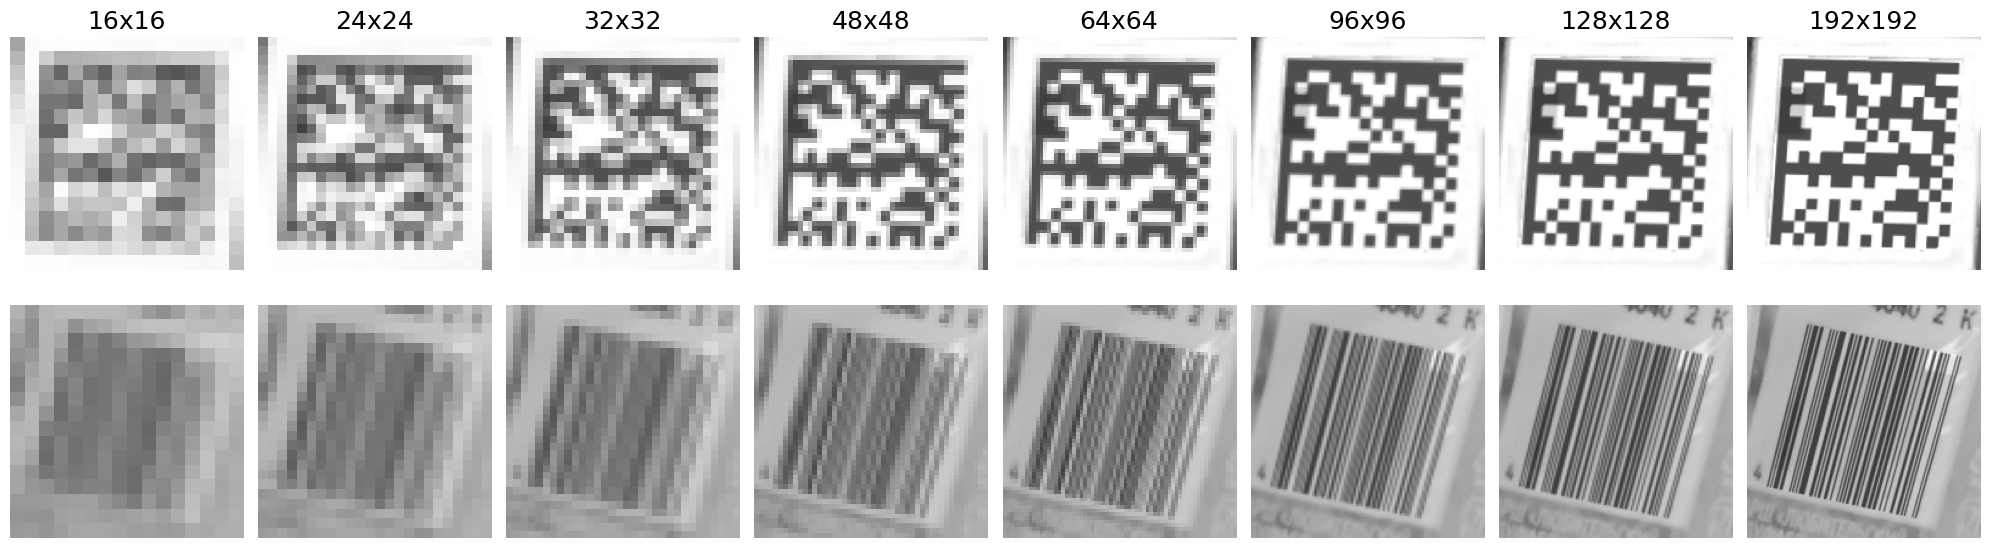

In [16]:
from classifiers.cnn_classifier import _preprocess_image

TWO_DIM_TYPES = {BarcodeType.QR_CODE, BarcodeType.DATA_MATRIX, BarcodeType.AZTEC, BarcodeType.PDF_417}

sample_2d = None
sample_1d = None
for b in barcodes.test:
    if sample_2d is not None and sample_1d is not None:
        break
    if b.marked_up_type in TWO_DIM_TYPES and sample_2d is None:
        b_copy = deepcopy(b)
        b_copy.do_preprocessing(MARGIN_RATE)
        if b_copy.image_array is not None:
            sample_2d = b_copy
    elif b.marked_up_type not in TWO_DIM_TYPES and sample_1d is None:
        b_copy = deepcopy(b)
        b_copy.do_preprocessing(MARGIN_RATE)
        if b_copy.image_array is not None:
            sample_1d = b_copy

sample_barcodes = [sample_2d, sample_1d]

fig, axes = plt.subplots(2, len(RESOLUTIONS), figsize=(2.5 * len(RESOLUTIONS), 6))

for img_idx, b in enumerate(sample_barcodes):
    sym_name = PRETTY_PRINT_MAP[b.marked_up_type]
    for res_idx, r in enumerate(RESOLUTIONS):
        arr = _preprocess_image(b.image_array, r)
        img_show = arr.transpose(1, 2, 0)
        ax = axes[img_idx][res_idx]
        ax.imshow(img_show)
        ax.set_title(f"{r}x{r}" if img_idx == 0 else "", fontsize=18)
        ax.set_ylabel(sym_name if res_idx == 0 else "", fontsize=18)
        ax.axis("off")

plt.tight_layout()
os.makedirs(GRAPHS_DIR, exist_ok=True)
plt.savefig(f"{GRAPHS_DIR}/cnn_barcode_resolutions.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close()


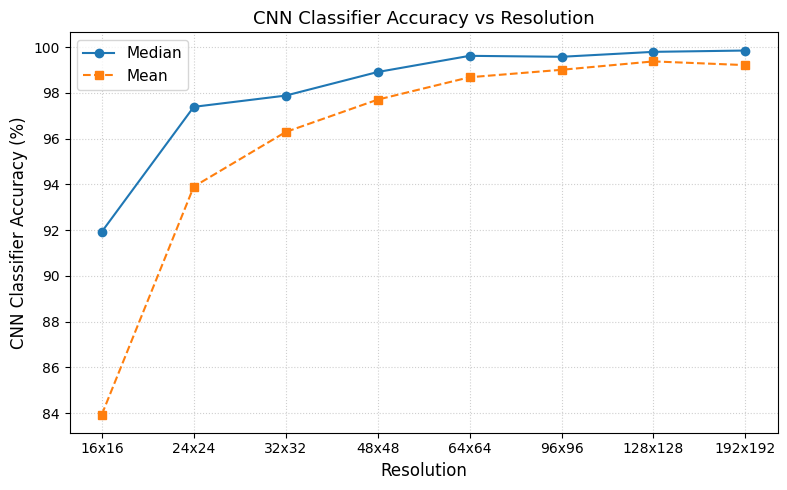

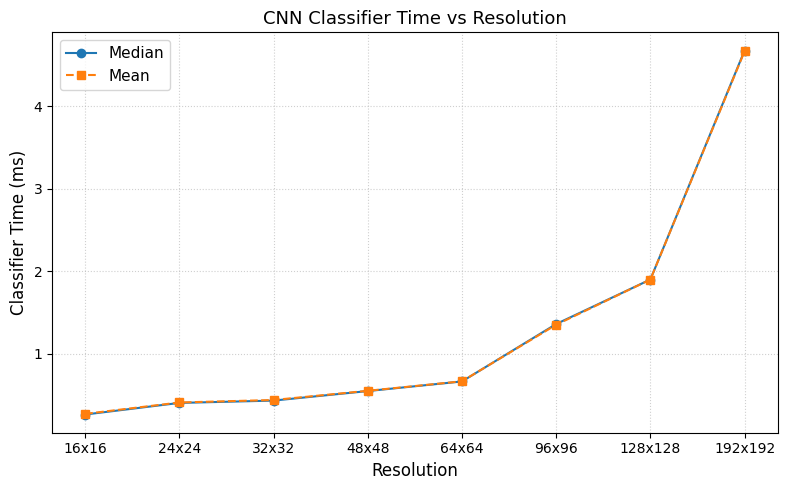

In [17]:
res_labels = [f"{r}x{r}" for r in RESOLUTIONS]

cnn_acc_medians_by_res = []
cnn_acc_means_by_res = []
cnn_time_medians_by_res = []
cnn_time_means_by_res = []

for r in RESOLUTIONS:
    acc_meds, acc_means, time_meds, time_means = [], [], [], []
    for p_idx, p in enumerate(PARTITIONS):
        per_sym, summary = build_stats(barcodes_cnn[r][p_idx])
        acc_meds.append(summary.loc["CNN Accuracy Median-of-Medians (%)", "Value"])
        acc_means.append(summary.loc["CNN Accuracy Mean-of-Medians (%)", "Value"])
        time_meds.append(summary.loc["ClassifierTime Median-of-Medians (ms)", "Value"])
        time_means.append(summary.loc["ClassifierTime Mean-of-Medians (ms)", "Value"])
    cnn_acc_medians_by_res.append(np.mean(acc_meds))
    cnn_acc_means_by_res.append(np.mean(acc_means))
    cnn_time_medians_by_res.append(np.mean(time_meds))
    cnn_time_means_by_res.append(np.mean(time_means))

os.makedirs(GRAPHS_DIR, exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(res_labels, cnn_acc_medians_by_res, marker="o", label="Median")
ax.plot(res_labels, cnn_acc_means_by_res, marker="s", linestyle="--", label="Mean")
ax.set_xlabel("Resolution", fontsize=12)
ax.set_ylabel("CNN Classifier Accuracy (%)", fontsize=12)
ax.set_title("CNN Classifier Accuracy vs Resolution", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.savefig(f"{GRAPHS_DIR}/cnn_accuracy_vs_resolution.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(res_labels, cnn_time_medians_by_res, marker="o", label="Median")
ax.plot(res_labels, cnn_time_means_by_res, marker="s", linestyle="--", label="Mean")
ax.set_xlabel("Resolution", fontsize=12)
ax.set_ylabel("Classifier Time (ms)", fontsize=12)
ax.set_title("CNN Classifier Time vs Resolution", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.savefig(f"{GRAPHS_DIR}/cnn_time_vs_resolution.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close()

In [18]:
save_group(CNN_TABLES_GROUP, "cnn_pipeline_all")
print("All CNN pipeline tables saved to latex_tables/cnn_pipeline_all.tex")

All CNN pipeline tables saved to latex_tables/cnn_pipeline_all.tex
